In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import datetime as dt

from warnings import filterwarnings
filterwarnings('ignore')

pd.set_option('display.max_columns', None)

In [4]:
data = pd.read_csv('customer_satisfaction.csv')
df = data.copy()

## Data Understanding
Before starting our analysis, it’s crucial to understand the structure of the dataset. We begin by examining the data types of each column, the total number of entries, the count of missing values, and the number of unique items in each column. This helps us identify the overall composition of the dataset and any potential issues such as missing or inconsistent data.

In [6]:
df.head()

,id,user_id,age,Gender,Date_Registered,Is_current_loyalty_program_member,loyalty_points_redeemed,loyalty_tier,Received_tier_discount_percentage,Received_card_discount_percentage,Received_coupon_discount_percentage,product_category,Product_value,transaction_id,order_id,payment_method,payment_datetime,purchased_datetime,purchase_medium,final_payment,released_date,estimated_delivery_date,received_date,shipping_method,tracking_number,customer_experience
0,0,****589084,44,O,2020-01-01,NO,5,NaN,NaN,3.0,3,office supplies,1003,***95994394,***242641,visa_c,2020-01-05 22:27:16,2020-01-05 22:27:16,online,1293.00,2020-01-12,2020-01-17,2020-01-17,standard,***9AWDD64SYI,neutral
1,1,****494191,36,O,2020-01-04,YES,4,1.0,3.0,4.0,1,electronics,4707,***68432956,***682463,amex,2020-01-06 00:37:51,2020-01-06 00:37:51,in-store,4522.44,2020-01-07,2020-01-12,2020-01-09,express,***3SSRORRZ0X,bad
2,2,****216469,40,F,2020-01-02,NO,3,NaN,NaN,3.0,5,pet supplies,5486,***66429391,***270784,mastercard_c,2020-01-07 03:02:35,2020-01-07 03:02:35,online,5628.00,2020-01-12,2020-01-18,2020-01-18,express,***2VSB7MH7FN,good
3,3,****707170,33,M,2020-01-06,YES,1,1.0,3.0,2.0,3,clothing,2121,***64300568,***976607,visa_c,2020-01-09 22:05:39,2020-01-09 22:05:39,in-store,2073.32,2020-01-13,2020-01-15,2020-01-17,express,***9XENHE2PKZ,bad
4,4,****066329,43,O,2020-01-06,YES,1,1.0,3.0,4.0,2,books,246,***54106959,***449807,visa_c,2020-01-11 08:32:22,2020-01-11 08:32:22,online,310.86,2020-01-15,2020-01-22,2020-01-20,express,***QTWLMEL0PE,bad


In [7]:
df.shape

(206969, 26)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 206969 entries, 0 to 206968
Data columns (total 26 columns):
 #   Column                               Non-Null Count   Dtype  
---  ------                               --------------   -----  
 0   id                                   206969 non-null  int64  
 1   user_id                              206969 non-null  object 
 2   age                                  206969 non-null  int64  
 3   Gender                               206969 non-null  object 
 4   Date_Registered                      206969 non-null  object 
 5   Is_current_loyalty_program_member    206969 non-null  object 
 6   loyalty_points_redeemed              206969 non-null  int64  
 7   loyalty_tier                         104902 non-null  float64
 8   Received_tier_discount_percentage    103590 non-null  float64
 9   Received_card_discount_percentage    50090 non-null   float64
 10  Received_coupon_discount_percentage  206969 non-null  int64  
 11  product_categ

In [9]:
for i in df.columns:
    print(i)
    print('No of unique Values:',df[i].nunique())
    print(df[i].unique())
    print('---')
    print()

id
No of unique Values: 206969
[     0      1      2 ... 206966 206967 206968]
---

user_id
No of unique Values: 186931
['****589084' '****494191' '****216469' ... '****016861' '****741534'
 '****773537']
---

age
No of unique Values: 44
[44 36 40 33 43 47 23 52 19 39 55 45 32 20 21 18 51 46 25 31 50 37 27 29
 60 30 24 56 58 26 41 59 49 38 35 54 28 22 57 42 34 48 53  0]
---

Gender
No of unique Values: 3
['O' 'F' 'M']
---

Date_Registered
No of unique Values: 1823
['2020-01-01' '2020-01-04' '2020-01-02' ... '2024-12-25' '2024-12-26'
 '2024-12-27']
---

Is_current_loyalty_program_member
No of unique Values: 2
['NO' 'YES']
---

loyalty_points_redeemed
No of unique Values: 6
[5 4 3 1 0 2]
---

loyalty_tier
No of unique Values: 4
[nan  1.  2.  4.  3.]
---

Received_tier_discount_percentage
No of unique Values: 4
[nan  3.  5. 10.  7.]
---

Received_card_discount_percentage
No of unique Values: 104
[  3.   4.   2.  nan   5.   1. 181. 175. 157. 169. 146. 135. 154. 153.
 185. 130. 117. 137. 18

In [10]:
df.nunique().sort_values(ascending=False)

id                                     206969
tracking_number                        206957
transaction_id                         206739
purchased_datetime                     206682
payment_datetime                       206682
order_id                               187196
user_id                                186931
final_payment                           32898
Product_value                           11583
Date_Registered                          1823
estimated_delivery_date                  1820
received_date                            1816
released_date                            1811
Received_coupon_discount_percentage       202
Received_card_discount_percentage         104
age                                        44
product_category                           20
payment_method                             13
loyalty_points_redeemed                     6
Received_tier_discount_percentage           4
loyalty_tier                                4
Gender                            

## Preliminary Analysis - 5 Point Summary

In [12]:
numeric = df.select_dtypes(include=np.number).columns.to_list()
categoric = df.select_dtypes(include=object).columns.to_list()

In [13]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,206969.0,103484.000000,59746.948269,0.0,51742.0,103484.0,155226.0,206968.0
age,206969.0,38.624668,12.800575,0.0,28.0,39.0,50.0,60.0
loyalty_points_redeemed,206969.0,2.472481,1.718771,0.0,1.0,2.0,4.0,5.0
loyalty_tier,104902.0,2.459762,1.127135,1.0,1.0,2.0,3.0,4.0
Received_tier_discount_percentage,103590.0,6.243875,2.582244,3.0,5.0,5.0,7.0,10.0
Received_card_discount_percentage,50090.0,10.780775,33.524402,1.0,2.0,3.0,4.0,199.0
Received_coupon_discount_percentage,206969.0,4.147244,18.867409,0.0,1.0,3.0,4.0,299.0
Product_value,206969.0,5322.859462,4304.731507,50.0,2563.0,5080.0,7592.0,49992.0
final_payment,206969.0,5142.777076,2847.272560,101.0,2680.0,5134.0,7591.0,10298.0


In [14]:
df[categoric].describe().T

,count,unique,top,freq
user_id,206969,186931,****256449,5
Gender,206969,3,F,69363
Date_Registered,206969,1823,2021-09-18,174
Is_current_loyalty_program_member,206969,2,YES,103590
product_category,206969,20,office supplies,10577
transaction_id,206969,206739,***45869915,2
order_id,206969,187196,***896762,5
payment_method,206969,13,amex,16122
payment_datetime,206969,206682,2024-07-06 16:38:06,2
purchased_datetime,206969,206682,2024-07-06 16:38:06,2


### Inference:

- **id**: Unique identifier, ranges from 0 to 206968. 
- **age**: Mean ~38.6 years, range 0–60. Notice that **0 age is unrealistic** → possible data quality issue.  
- **loyalty_points_redeemed**: Average ~2.47, range 0–5.  
- **loyalty_tier**: Mean ~2.46, range 1–4, missing ~50% values (already noted).  

#### Discounts: 
- **Tier Discount**: 50 % of the values are missing.
- **Card discount**: Mean ~10.7%, very high variance (std ~33.5).  
- **Coupon discount**: Mean ~4.1%.  

#### Monetary Features:
- **Product_value**: Average ~₹5,322, large spread (std ~₹4,304).  
- **final_payment**: Average ~₹5,142, std ~₹2,847.  

---

### Key Insights
1. `age=0` entries → likely erroneous, need cleaning.  
2. Discount percentages (*card and coupon*) show **heavy outliers**, may need capping or log-transform.  
3. Loyalty features have missing values & limited range → may or may not add strong predictive power.  
4. Received_card_discount_percentage: Indicates presence of extreme outliers as mean value is greater than median. 
5. Product_value: Shows a long right tail distribution.


## Handling Missing Values

In [17]:
df.isnull().sum()/ len(df)  * 100 # percentage of missing values

id                                      0.000000
user_id                                 0.000000
age                                     0.000000
Gender                                  0.000000
Date_Registered                         0.000000
Is_current_loyalty_program_member       0.000000
loyalty_points_redeemed                 0.000000
loyalty_tier                           49.315115
Received_tier_discount_percentage      49.949026
Received_card_discount_percentage      75.798308
Received_coupon_discount_percentage     0.000000
product_category                        0.000000
Product_value                           0.000000
transaction_id                          0.000000
order_id                                0.000000
payment_method                          0.000000
payment_datetime                        0.000000
purchased_datetime                      0.000000
purchase_medium                         0.000000
final_payment                           0.000000
released_date       

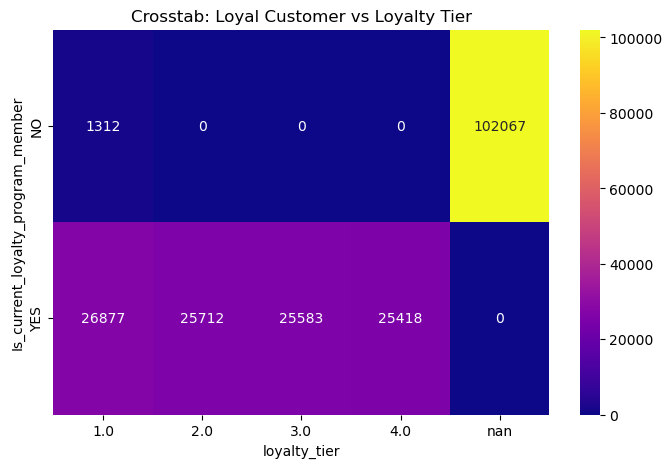

In [18]:
# Check relationship between loyalty membership and loyalty_tier
ct = pd.crosstab(df['Is_current_loyalty_program_member'], df['loyalty_tier'], dropna=False)

plt.figure(figsize=(8,5))
sns.heatmap(ct, annot=True, fmt='d', cmap='plasma')
plt.title("Crosstab: Loyal Customer vs Loyalty Tier")
plt.show()

In [19]:
# Loyalty tier missingness by membership
df.groupby('Is_current_loyalty_program_member')['loyalty_tier'].apply(lambda x: x.isna().sum())

Is_current_loyalty_program_member
NO     102067
YES         0
Name: loyalty_tier, dtype: int64

In [20]:
# Loyalty tier discount missingness by membership
df.groupby('Is_current_loyalty_program_member')['Received_tier_discount_percentage'].apply(lambda x: x.isna().sum())

Is_current_loyalty_program_member
NO     103379
YES         0
Name: Received_tier_discount_percentage, dtype: int64

In [21]:
# Loyalty Tier: fill missing with 0 (means no tier)
df['loyalty_tier'] = df['loyalty_tier'].fillna(0)

# Discounts: fill missing with 0 (means no discount received)
df['Received_tier_discount_percentage'] = df['Received_tier_discount_percentage'].fillna(0)

In [22]:
payment_map = {
    'visa_c': 'Card',
    'visa_d': 'Card',
    'mastercard_c': 'Card',
    'mastercard_d': 'Card',
    'amex': 'Card',

    'gcash': 'E-Wallet',
    'maya': 'E-Wallet',
    'grabpay': 'E-Wallet',
    'shopeepay': 'E-Wallet',
    'coinsph': 'E-Wallet',

    'cash': 'Cash',
    'otc': 'Over-the-Counter',

    'bank_transfer': 'Bank Transfer'
}


df['payment_method_grouped'] = df['payment_method'].map(payment_map)

In [23]:
df["payment_method_grouped"].unique()

array(['Card', 'E-Wallet', 'Cash', 'Bank Transfer', 'Over-the-Counter'],
      dtype=object)

<Axes: xlabel='Received_card_discount_percentage', ylabel='payment_method_grouped'>

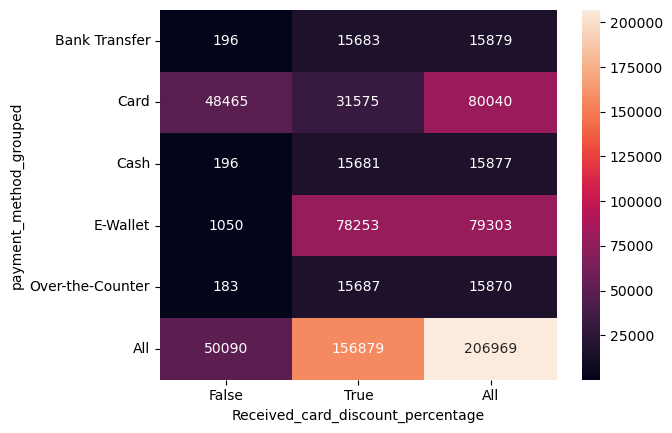

In [24]:
sns.heatmap(pd.crosstab(
    df['payment_method_grouped'],
    df['Received_card_discount_percentage'].isna(),
    margins=True),annot=True,fmt="d")

In [25]:
# Discounts: fill missing with 0 (means no discount received)
df['Received_card_discount_percentage'] = df['Received_card_discount_percentage'].fillna(0)

In [26]:
df.isnull().sum().sum()

0

In [27]:
df.drop(columns='payment_method', inplace=True)

## Handling Duplicates

In [29]:
duplicates = df[df.drop(columns=['id']).duplicated()]
len(duplicates)

12

In [30]:
df = df[~df.drop(columns=['id']).duplicated()]

### Date Time

In [32]:
def date_time(df):
    date_columns = ['Date_Registered', 'payment_datetime', 'purchased_datetime', 
                    'released_date', 'estimated_delivery_date', 'received_date']
    for col in date_columns:
        df[col] = pd.to_datetime(df[col], errors='coerce')

    return df

df = date_time(df)

In [33]:
len(df)

206957

In [34]:
df.isnull().sum()

id                                     0
user_id                                0
age                                    0
Gender                                 0
Date_Registered                        0
Is_current_loyalty_program_member      0
loyalty_points_redeemed                0
loyalty_tier                           0
Received_tier_discount_percentage      0
Received_card_discount_percentage      0
Received_coupon_discount_percentage    0
product_category                       0
Product_value                          0
transaction_id                         0
order_id                               0
payment_datetime                       0
purchased_datetime                     0
purchase_medium                        0
final_payment                          0
released_date                          0
estimated_delivery_date                0
received_date                          0
shipping_method                        0
tracking_number                        0
customer_experie

### Dropping Unneccesary Columns

In [62]:
df = df.drop(columns= ['id', 'transaction_id', 'order_id','tracking_number'])

## Deep Analysis

### Understanding Target Variable - Imbalance Check

In [37]:
target = df['customer_experience']

In [38]:
class_counts = df['customer_experience'].value_counts(normalize=True)*100
class_counts

customer_experience
good       44.154100
bad        33.115575
neutral    22.730326
Name: proportion, dtype: float64

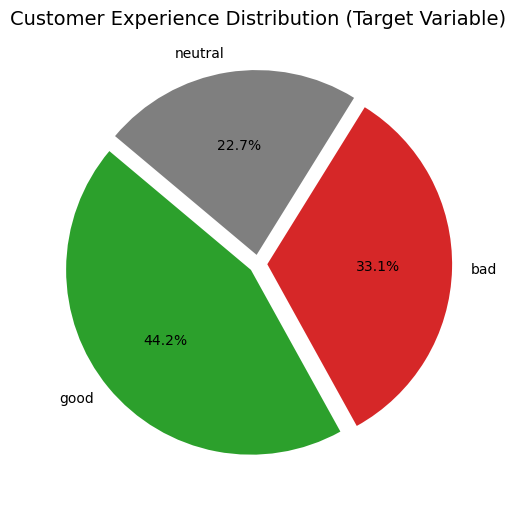

In [39]:
# Pie chart
colors = ['#2ca02c', '#d62728','#7f7f7f']  # Good, Bad, Neutral
explode = [0.05, 0.05, 0.05]

plt.figure(figsize=(6,6))
plt.pie(class_counts, 
        labels=class_counts.index, 
        autopct='%1.1f%%', 
        startangle=140, 
        colors = colors,
        explode=explode)  

plt.title('Customer Experience Distribution (Target Variable)', fontsize=14)
plt.show()

### Univariate Analysis(Numeric)

In [41]:
num = df.select_dtypes(include=np.number).columns.to_list()
cat = df.select_dtypes(include=object).columns.to_list()

In [42]:
plt.rcParams['figure.figsize'] = [15,15]

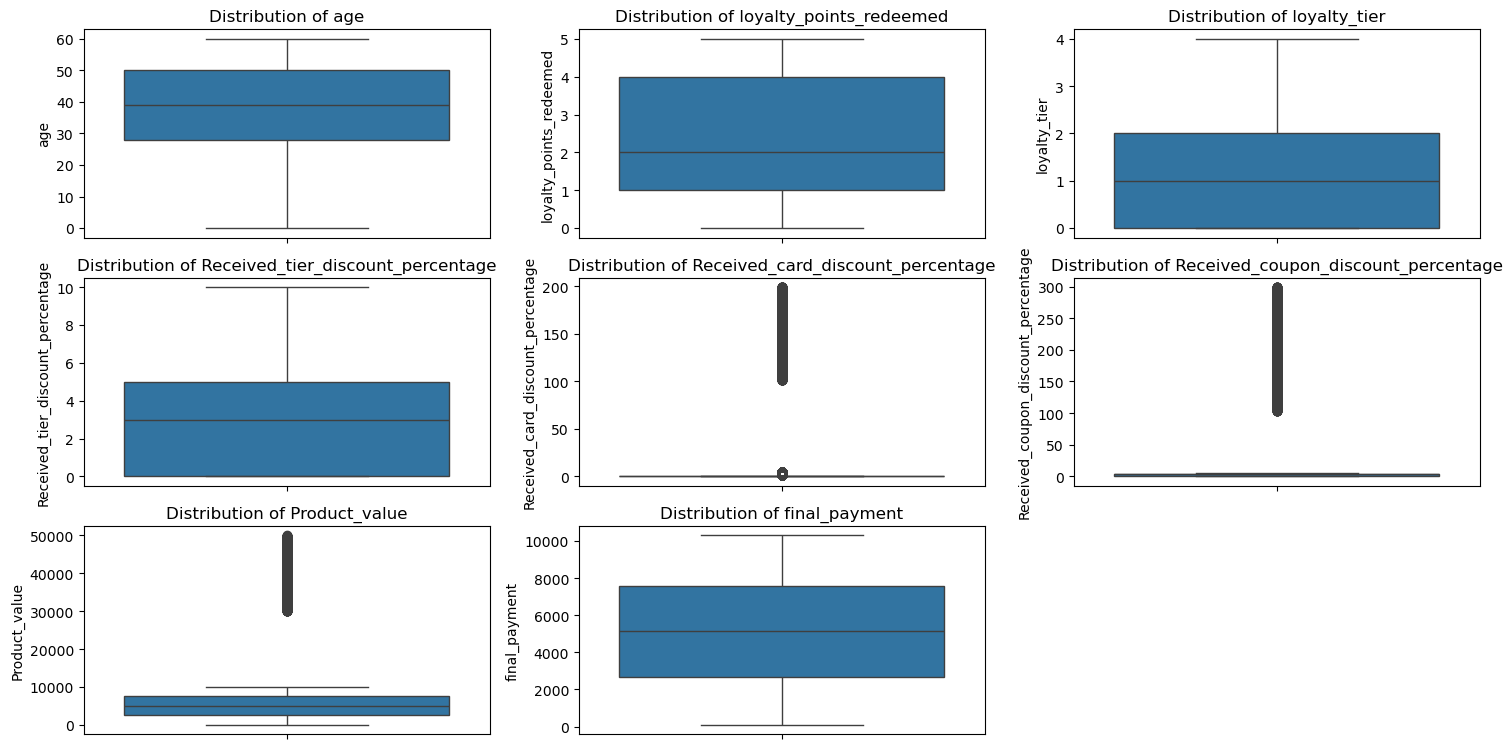

In [43]:
t=1
for i in num:
    plt.subplot(6,3,t)
    sns.boxplot(y=df[i])
    plt.title(f'Distribution of {i}')
    t+=1
    
plt.tight_layout()
plt.show()

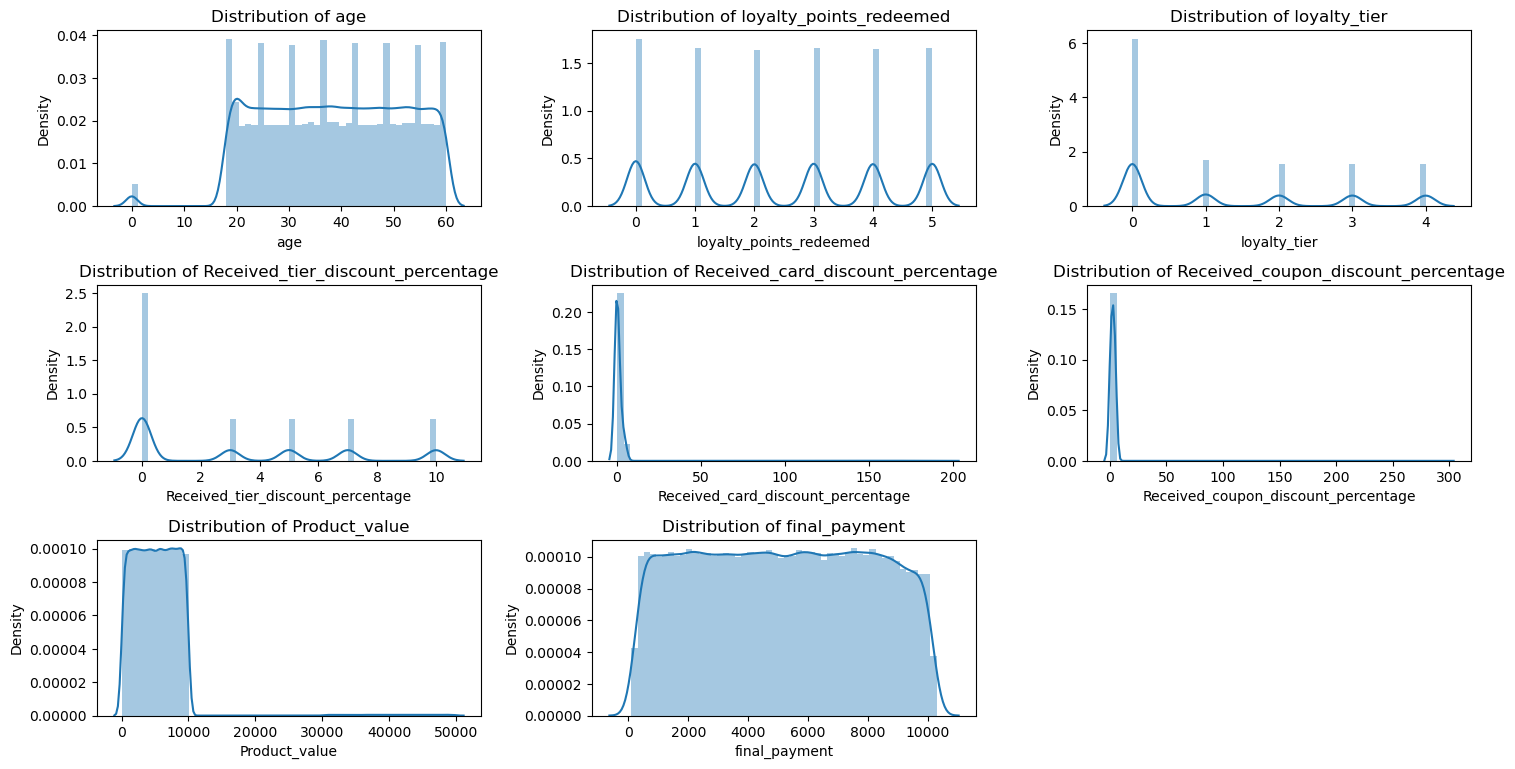

In [44]:
# kde plot
t=1
for i in num:
    plt.subplot(6,3,t)
    sns.distplot(df[i])
    plt.title(f'Distribution of {i}')
    t+=1
    
plt.tight_layout()
plt.show()

In [64]:
df = df[df['age'] > 0]
df

,user_id,age,Gender,Date_Registered,Is_current_loyalty_program_member,loyalty_points_redeemed,loyalty_tier,Received_tier_discount_percentage,Received_card_discount_percentage,Received_coupon_discount_percentage,product_category,Product_value,payment_datetime,purchased_datetime,purchase_medium,final_payment,released_date,estimated_delivery_date,received_date,shipping_method,customer_experience,payment_method_grouped
0,****589084,44,O,2020-01-01,NO,5,0.0,0.0,3.0,3,office supplies,1003,2020-01-05 22:27:16,2020-01-05 22:27:16,online,1293.00,2020-01-12,2020-01-17,2020-01-17,standard,neutral,Card
1,****494191,36,O,2020-01-04,YES,4,1.0,3.0,4.0,1,electronics,4707,2020-01-06 00:37:51,2020-01-06 00:37:51,in-store,4522.44,2020-01-07,2020-01-12,2020-01-09,express,bad,Card
2,****216469,40,F,2020-01-02,NO,3,0.0,0.0,3.0,5,pet supplies,5486,2020-01-07 03:02:35,2020-01-07 03:02:35,online,5628.00,2020-01-12,2020-01-18,2020-01-18,express,good,Card
3,****707170,33,M,2020-01-06,YES,1,1.0,3.0,2.0,3,clothing,2121,2020-01-09 22:05:39,2020-01-09 22:05:39,in-store,2073.32,2020-01-13,2020-01-15,2020-01-17,express,bad,Card
4,****066329,43,O,2020-01-06,YES,1,1.0,3.0,4.0,2,books,246,2020-01-11 08:32:22,2020-01-11 08:32:22,online,310.86,2020-01-15,2020-01-22,2020-01-20,express,bad,Card
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
206964,****708759,19,M,2024-12-18,NO,4,0.0,0.0,3.0,0,furniture,5375,2024-12-28 23:51:36,2024-12-28 23:51:36,online,5533.00,2024-12-31,2025-01-02,2024-12-31,standard,bad,Card
206965,****074598,54,M,2024-12-27,NO,2,0.0,0.0,1.0,0,sports,4777,2024-12-28 23:54:24,2024-12-28 23:54:24,online,4910.00,2024-12-30,2025-01-01,2025-01-02,standard,bad,Card
206966,****016861,25,O,2024-12-02,YES,4,4.0,10.0,4.0,5,office supplies,5479,2024-12-28 23:57:17,2024-12-28 23:57:17,in-store,4558.99,2025-01-04,2025-01-11,2025-01-10,express,bad,Card
206967,****741534,54,M,2024-12-12,NO,0,0.0,0.0,0.0,3,clothing,8724,2024-12-28 23:57:28,2024-12-28 23:57:28,online,8900.00,2024-12-30,2025-01-04,2025-01-06,standard,good,E-Wallet


### Outlier Treatment

In [47]:
out=["Received_card_discount_percentage","Received_coupon_discount_percentage","Product_value"]
iqr=df[out].quantile(0.75)-df[out].quantile(0.25)
uw=df[out].quantile(0.75)+iqr*1.5
lw=df[out].quantile(0.25)-iqr*1.5
outliers=df[((df[out] < lw) | (df[out] > uw)).any(axis=1)]
len(outliers)/len(df)

0.24337085754577062

In [48]:
outliers.describe().T

,count,mean,min,25%,50%,75%,max,std
age,50048.0,38.540701,18.0,27.0,38.0,50.0,60.0,12.632252
Date_Registered,50048,2022-06-28 13:52:07.557544704,2020-01-01 00:00:00,2021-03-29 00:00:00,2022-06-29 00:00:00,2023-09-27 00:00:00,2024-12-27 00:00:00,NaN
loyalty_points_redeemed,50048.0,2.435462,0.0,1.0,2.0,4.0,5.0,1.727214
loyalty_tier,50048.0,1.232936,0.0,0.0,1.0,2.0,4.0,1.45552
Received_tier_discount_percentage,50048.0,3.097606,0.0,0.0,0.0,5.0,10.0,3.610328
Received_card_discount_percentage,50048.0,6.870185,0.0,2.0,3.0,4.0,199.0,24.237876
Received_coupon_discount_percentage,50048.0,9.21865,0.0,1.0,3.0,4.0,299.0,37.520645
Product_value,50048.0,6216.552609,50.0,2614.75,5231.0,7794.0,49992.0,7009.19585
payment_datetime,50048,2023-10-02 16:31:24.703704320,2020-01-05 22:27:16,2023-02-05 19:24:14,2024-01-25 19:54:32.500000,2024-08-26 08:51:37.500000,2024-12-28 23:57:17,NaN
purchased_datetime,50048,2023-10-02 16:31:24.703704320,2020-01-05 22:27:16,2023-02-05 19:24:14,2024-01-25 19:54:32.500000,2024-08-26 08:51:37.500000,2024-12-28 23:57:17,NaN


### Outlier Columns in dataframe based on Boxplots
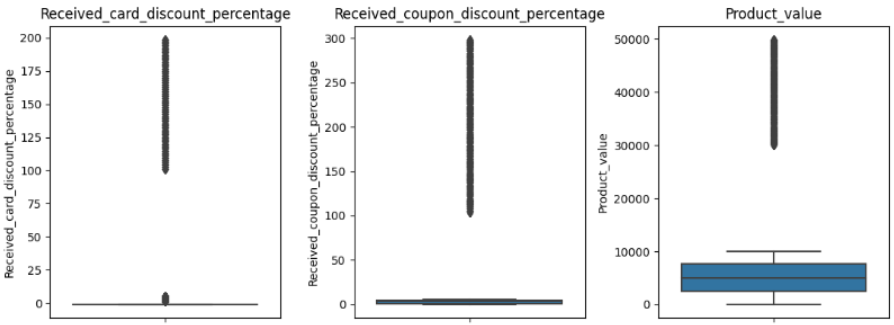

Referring to these boxplots, we observe outliers in the `df` dataset. Specifically:  

- `product_value` > 10,000  
- `Received_card_discount_percentage` > 4  
- `Received_coupon_discount_percentage` > 4

- The Reason we are taking 4 for discount values as the outliers 75 % range is upto value 4 and for product_value, it is around 10,000 based on the plot

In [92]:
df['Product_value'].quantile(0.99)

9981.0

In [80]:
iqr=df['Product_value'].quantile(0.75)-df['Product_value'].quantile(0.25)

In [88]:
df['Product_value'].quantile(0.75)+iqr*1.5

15137.0

In [94]:
df['Received_coupon_discount_percentage'].quantile(0.99)


5.0

In [ ]:
df['Product_value'].quantile(0.95)


In [50]:
df.shape

(205645, 22)

### Univariate Analysis(Categoric)

In [52]:
cat = df.drop(columns=['customer_experience', 'user_id']).select_dtypes(include=object).columns.to_list()

In [53]:
cat

['Gender',
 'Is_current_loyalty_program_member',
 'product_category',
 'purchase_medium',
 'shipping_method',
 'payment_method_grouped']

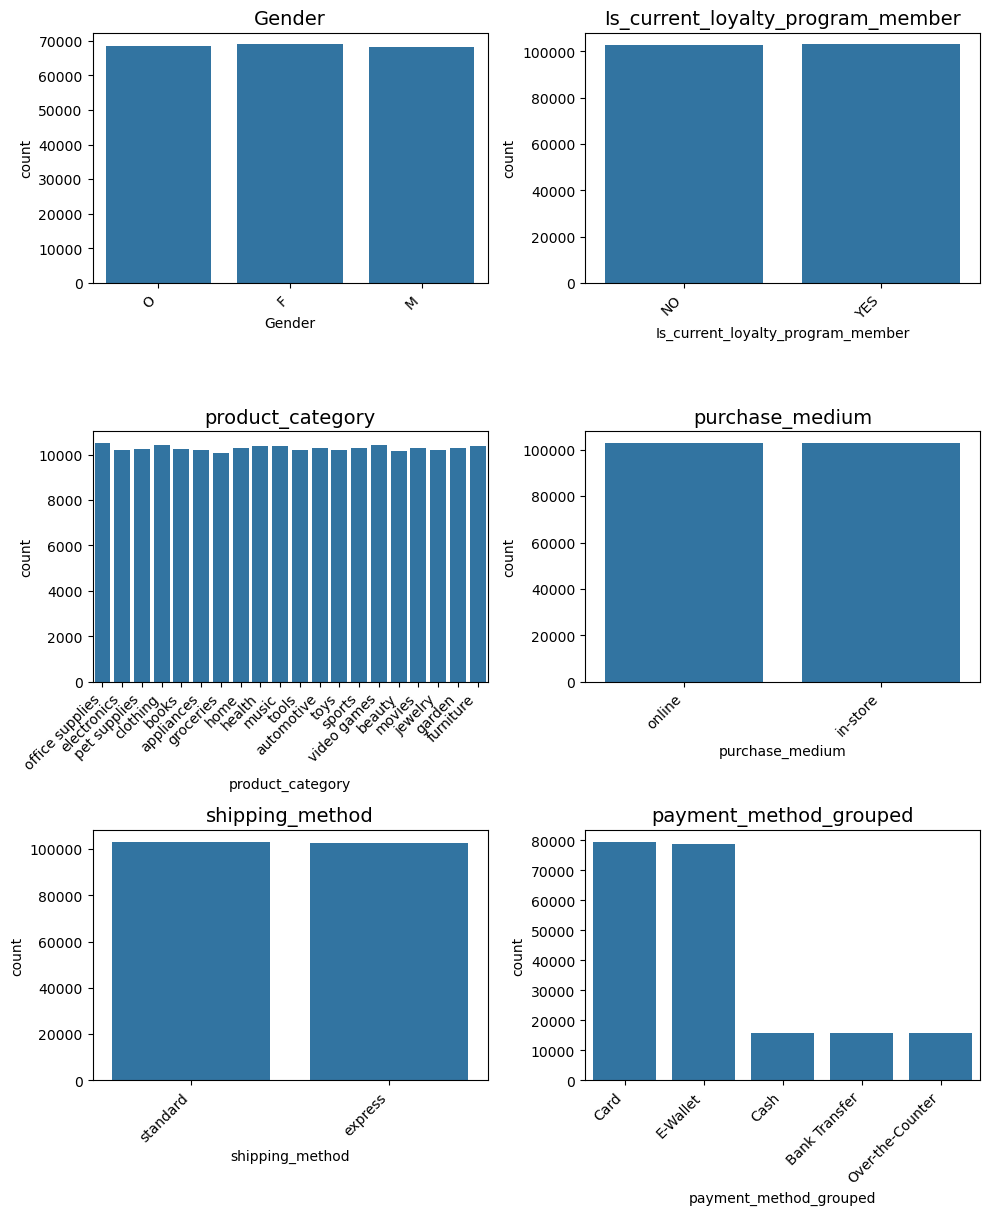

In [54]:
t=1
plt.figure(figsize=(10, 15))
for i in cat:
    plt.subplot(4,2,t)
    sns.countplot(x=df[i])
    plt.title(f'{i}', fontsize=14)
    plt.xticks(rotation=45, ha='right')
    t=t+1

plt.tight_layout()
plt.show()

## Bi- variate Analysis: Numeric vs Target

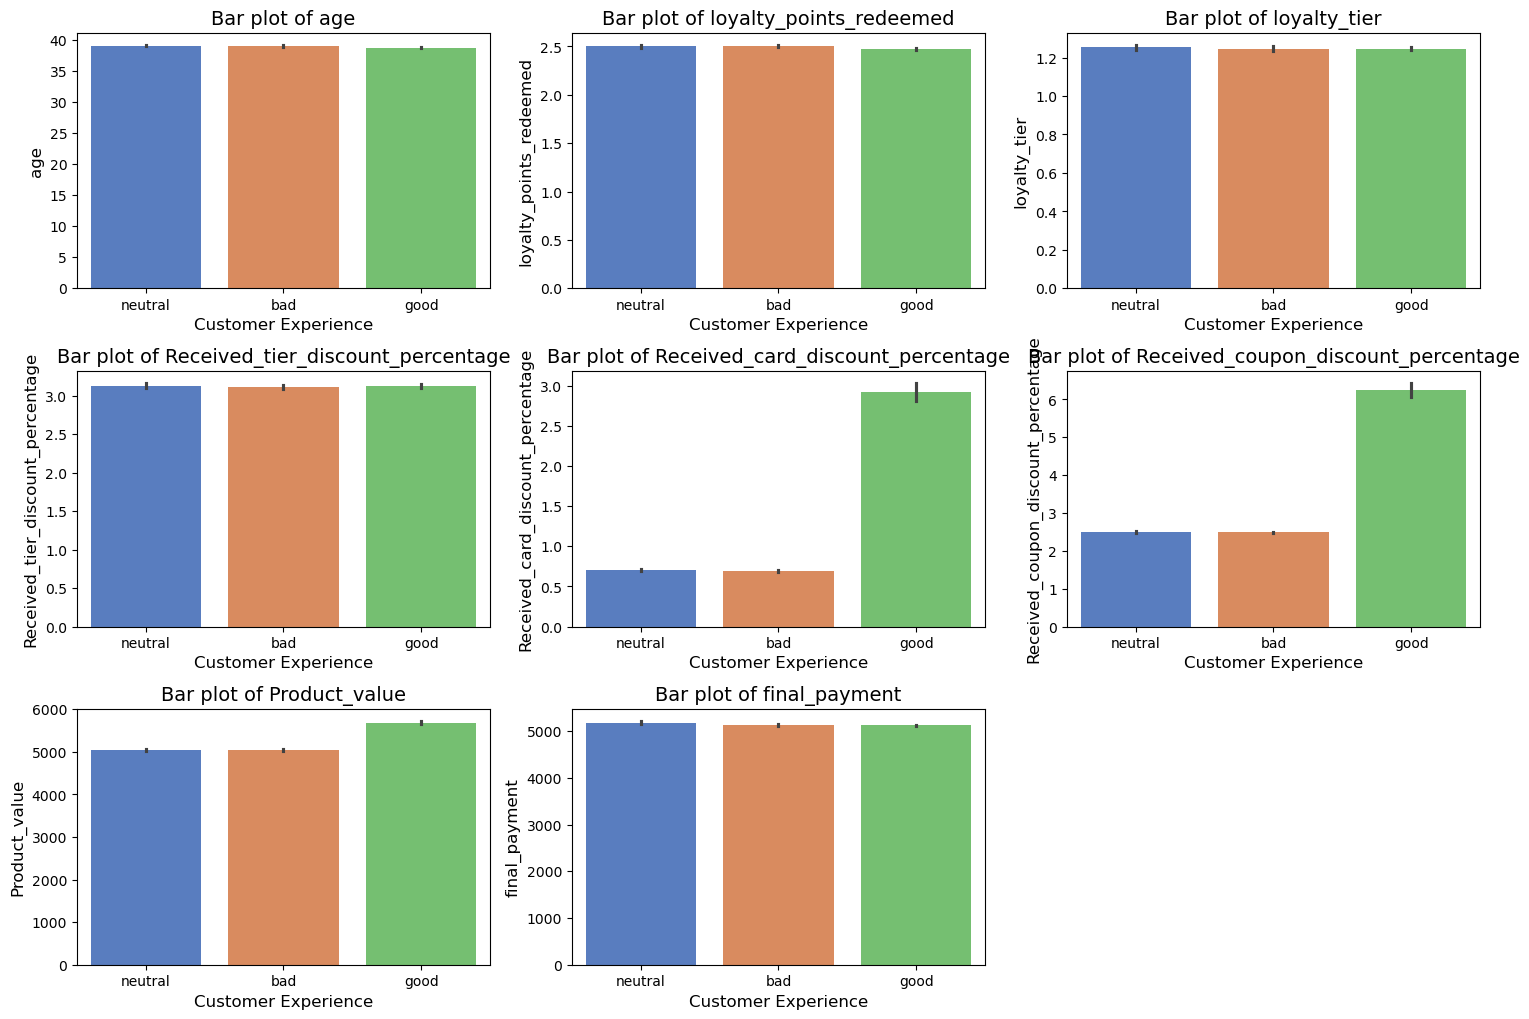

In [56]:
t=1
plt.figure(figsize=(15, 20))
for i in num:
    plt.subplot(6, 3, t)
    sns.barplot(data=df, x='customer_experience', y=i, palette="muted")
    plt.title(f'Bar plot of {i}', fontsize=14)
    plt.xlabel('Customer Experience', fontsize=12)
    plt.ylabel(i, fontsize=12)
    plt.tight_layout()
    t=t+1

plt.show()

## Bi- variate Analysis: Categorical vs Target

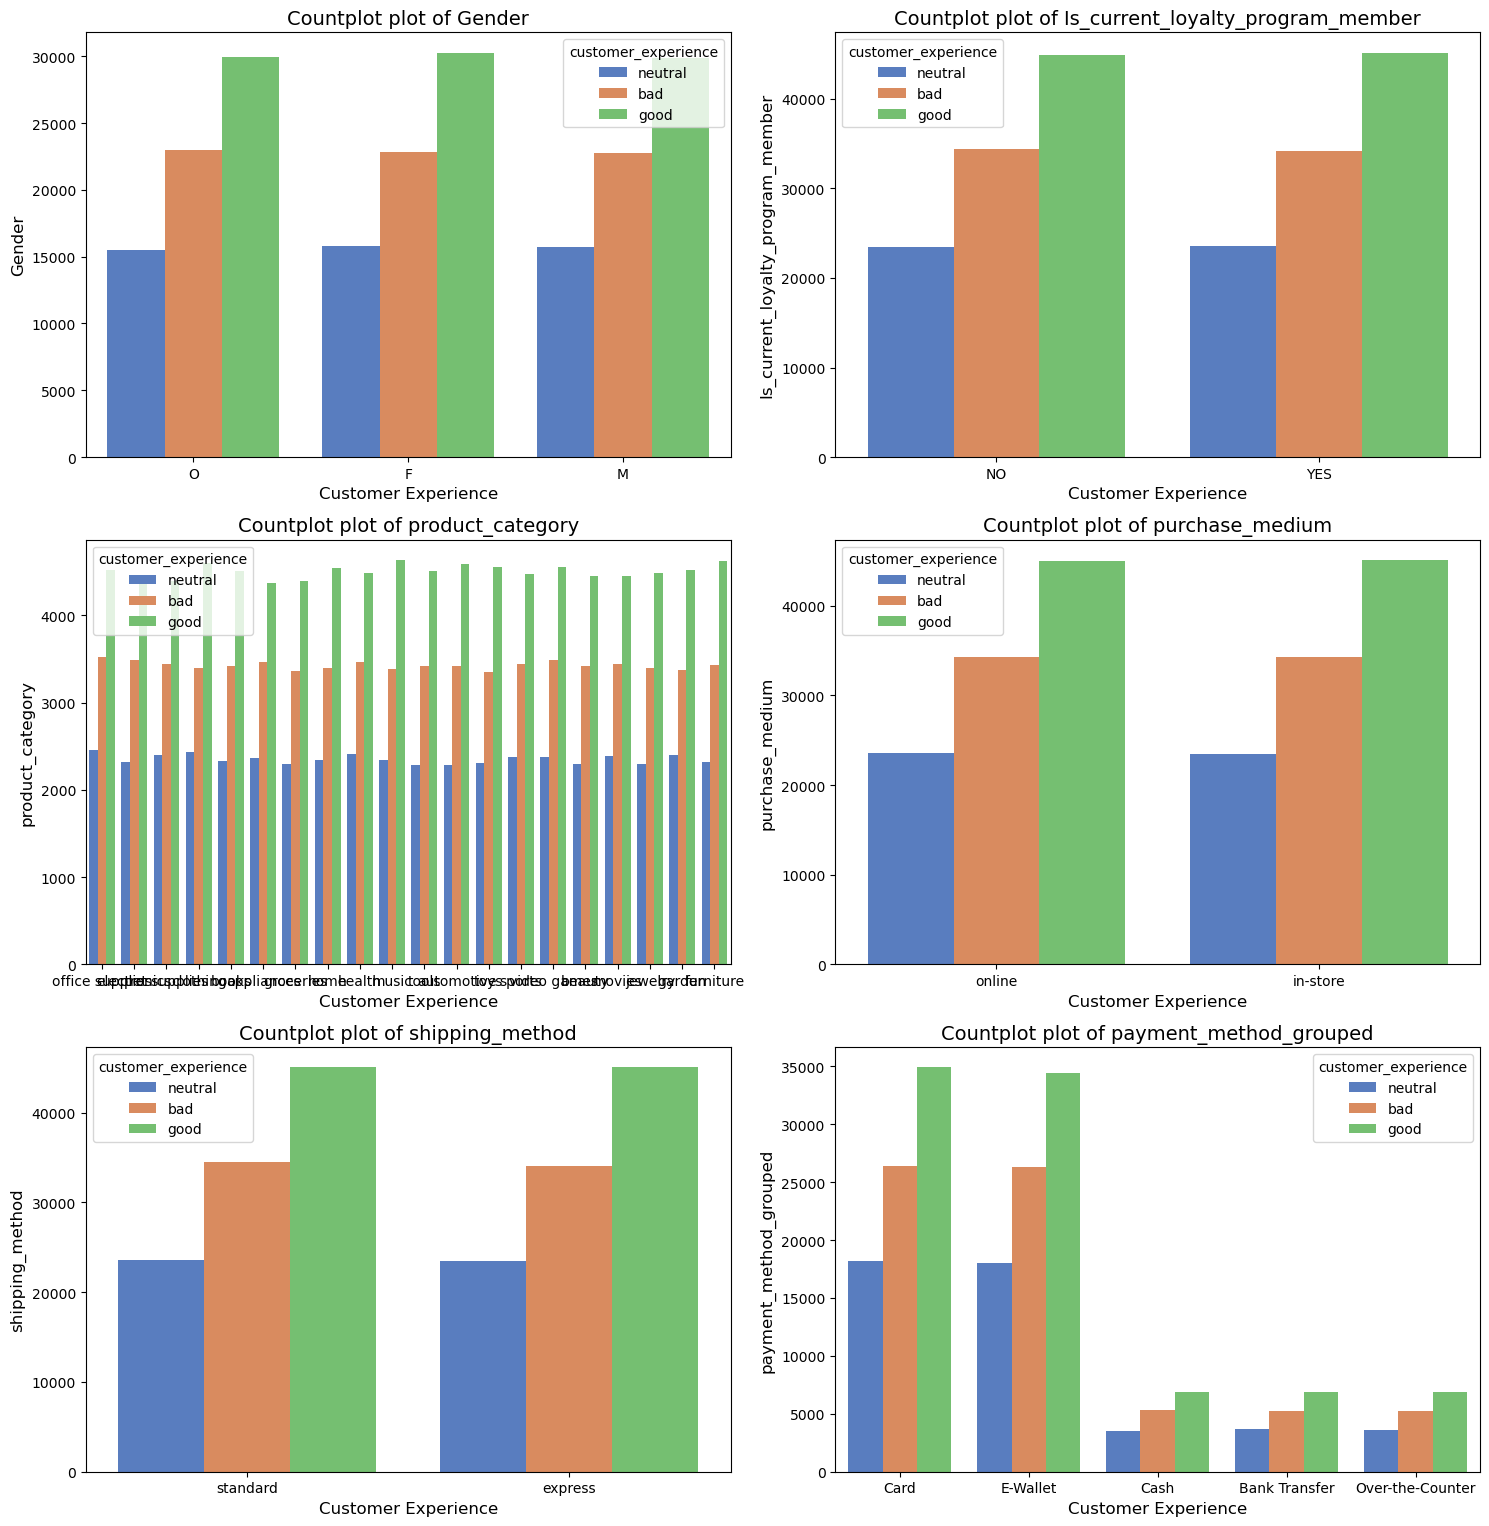

In [58]:
t=1
plt.figure(figsize=(15, 20))
for i in cat:
    plt.subplot(4, 2, t)
    sns.countplot(data=df, hue='customer_experience', x=i, palette="muted")
    plt.title(f'Countplot plot of {i}', fontsize=14)
    plt.xlabel('Customer Experience', fontsize=12)
    plt.ylabel(i, fontsize=12)
    plt.tight_layout()
    t=t+1

plt.show()

### Feature Engineering

In [97]:
def process_dataframe(df):

    # Financial Features
    # Discount amount features
    df['total_discount_percentage'] = df['Received_tier_discount_percentage'] + df['Received_card_discount_percentage'] + df['Received_coupon_discount_percentage']
    df['Total_Discount_Amount'] = df['Product_value'] * ((df['total_discount_percentage']) / 100)
    
    # shipping cost calculation
    df['shipping_cost'] = df['final_payment'] - (df['Product_value'] - df['Total_Discount_Amount'])
        
    # Loyalty Features
    df['loyalty_engagement_score'] = df['loyalty_points_redeemed'] / df['Product_value']
    
    # Temporal Features
    # Purchase timing
    df['purchase_hour'] = df['purchased_datetime'].dt.hour
    df['purchase_day_of_week'] = df['purchased_datetime'].dt.dayofweek
    df['is_business_hours'] = ((df['purchase_hour'] >= 9) & (df['purchase_hour'] <= 17)).astype(int)
    df['purchase_month'] = df['purchased_datetime'].dt.month
    df['purchase_quarter'] = df['purchased_datetime'].dt.quarter
    
    # Delivery Features
    df['receive_day_of_week'] = df['received_date'].dt.dayofweek
    df['processing_days'] = (df['released_date'] - df['purchased_datetime']).dt.days
    df['delivery_days'] = (df['received_date'] - df['released_date']).dt.days
    df['total_order_days'] = (df['received_date'] - df['purchased_datetime']).dt.days
    df['delivery_delay'] = (df['received_date'] - df['estimated_delivery_date']).dt.days
    df['is_delayed'] = (df['delivery_delay'] > 0).astype(int)
    
    # Customer Features
    df['age_group'] = pd.cut(df['age'], 
                            bins=[0, 25, 35, 50, 65], 
                            labels=[0, 1, 2, 3])
    
    return df

In [99]:
df = process_dataframe(df)

In [101]:
df.drop(columns=['user_id'], inplace=True)

In [103]:
cat=df.select_dtypes(include=object).columns.to_list()
for i in cat:
    print(i)
    print(df[i].nunique())
    print("*"*50)

Gender
3
**************************************************
Is_current_loyalty_program_member
2
**************************************************
product_category
20
**************************************************
purchase_medium
2
**************************************************
shipping_method
2
**************************************************
customer_experience
3
**************************************************
payment_method_grouped
5
**************************************************


## Pre-Proccessing

### Encoding

In [107]:
from sklearn.preprocessing import LabelEncoder
lab = LabelEncoder()
lab_col = ['product_category', 'payment_method_grouped']
for i in lab_col:
    df[i] = lab.fit_transform(df[i])

In [108]:
cols_to_encode = [
    'Gender', 'Is_current_loyalty_program_member', 'purchase_medium',
    'shipping_method'
]
df = pd.get_dummies(df, columns=cols_to_encode,dtype=int,drop_first=True)

In [109]:
# encoding Target variable
experience_map = {
    'bad': 0,
    'neutral': 1,
    'good': 2
}

df['customer_experience'] = df['customer_experience'].map(experience_map)

### Transformation

In [114]:
num = df.select_dtypes(include=np.number).columns.to_list()

In [116]:
df[num].skew()

age                                       0.005583
loyalty_points_redeemed                   0.006752
loyalty_tier                              0.728955
Received_tier_discount_percentage         0.703820
Received_card_discount_percentage        12.609405
Received_coupon_discount_percentage      11.928097
product_category                         -0.001607
Product_value                             4.615651
final_payment                             0.011297
customer_experience                      -0.204045
payment_method_grouped                    0.006585
total_discount_percentage                 8.894109
Total_Discount_Amount                    12.560471
shipping_cost                            14.339805
loyalty_engagement_score                 10.165311
purchase_hour                            -0.000320
purchase_day_of_week                     -0.005781
is_business_hours                         0.519014
purchase_month                           -0.312705
purchase_quarter               

In [118]:
trans=["Received_card_discount_percentage","Received_coupon_discount_percentage","Total_Discount_Amount","shipping_cost","loyalty_engagement_score","Product_value"]

In [120]:
from sklearn.preprocessing import PowerTransformer
pt=PowerTransformer()
for i in trans:
    df[i]=pt.fit_transform(df[[i]])

### Scaling

In [122]:
sca=df.drop("customer_experience",axis=1)

In [123]:
from sklearn.preprocessing import StandardScaler
sc=StandardScaler()

In [127]:
for i in sca:
    df[i]=sc.fit_transform(df[[i]])

## Multicolinearity

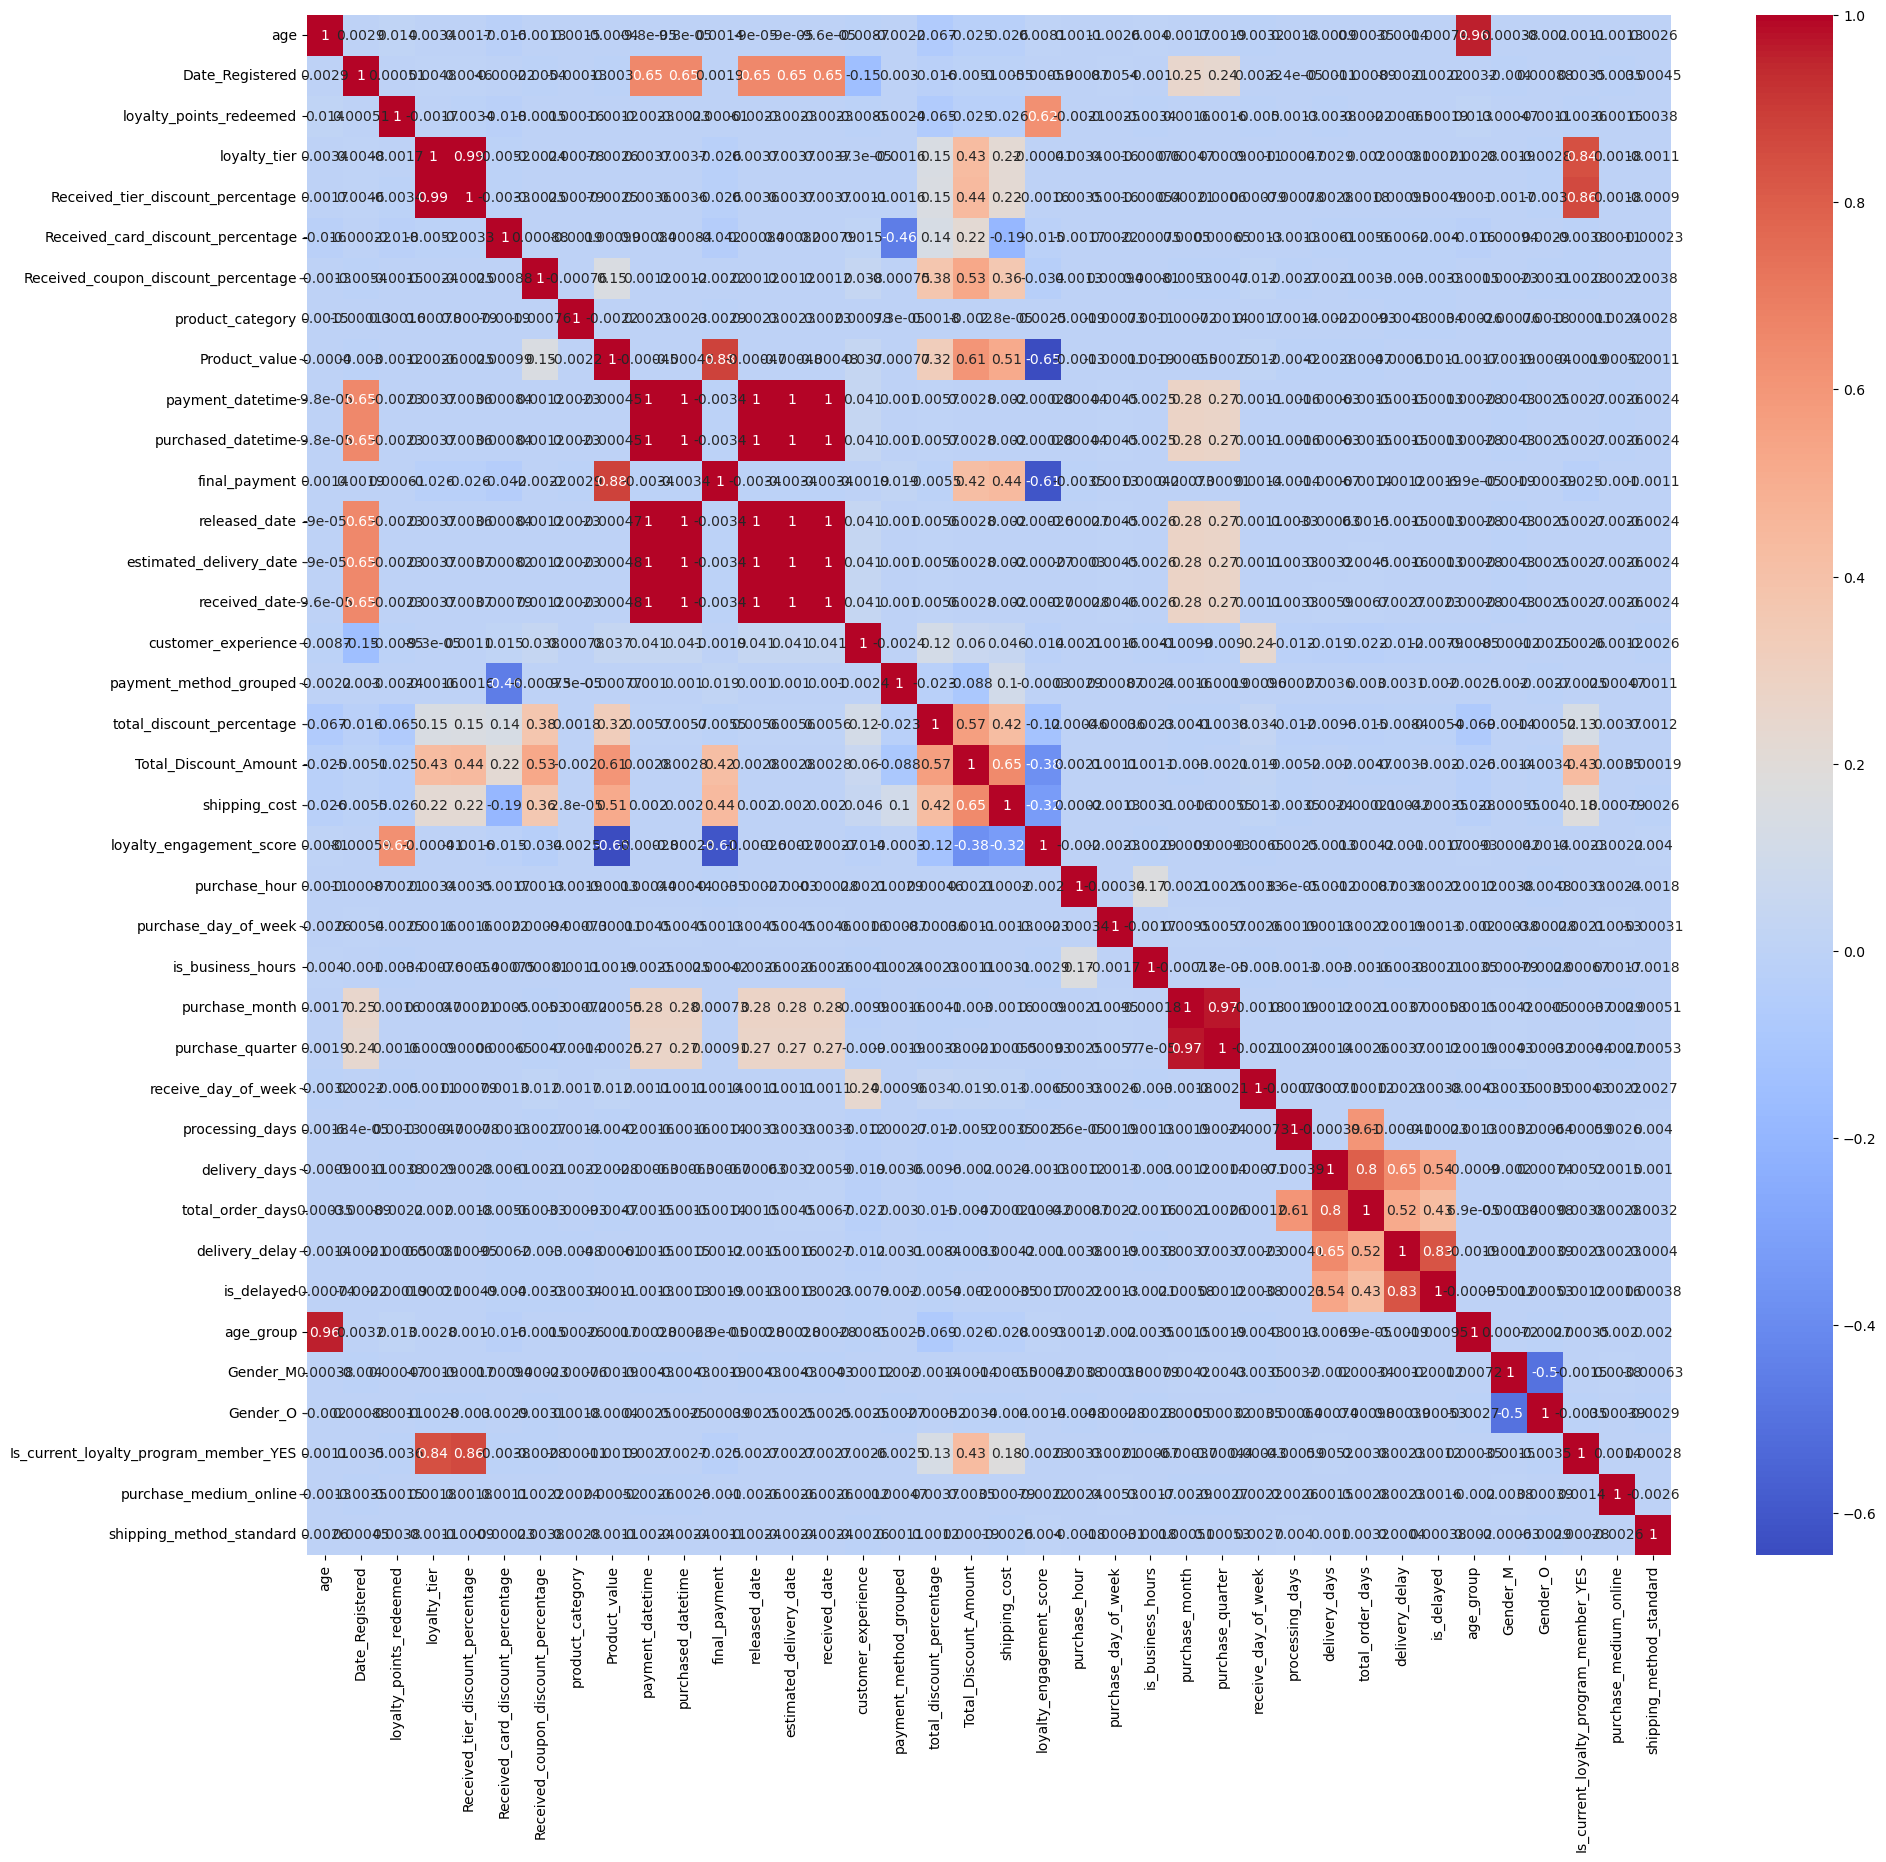

In [79]:
plt.figure(figsize=(22, 20))  # around 0.5 × 45 in each dimension
sns.heatmap(df.corr(), cmap="coolwarm", annot=True)
plt.show()

## Feature Selection

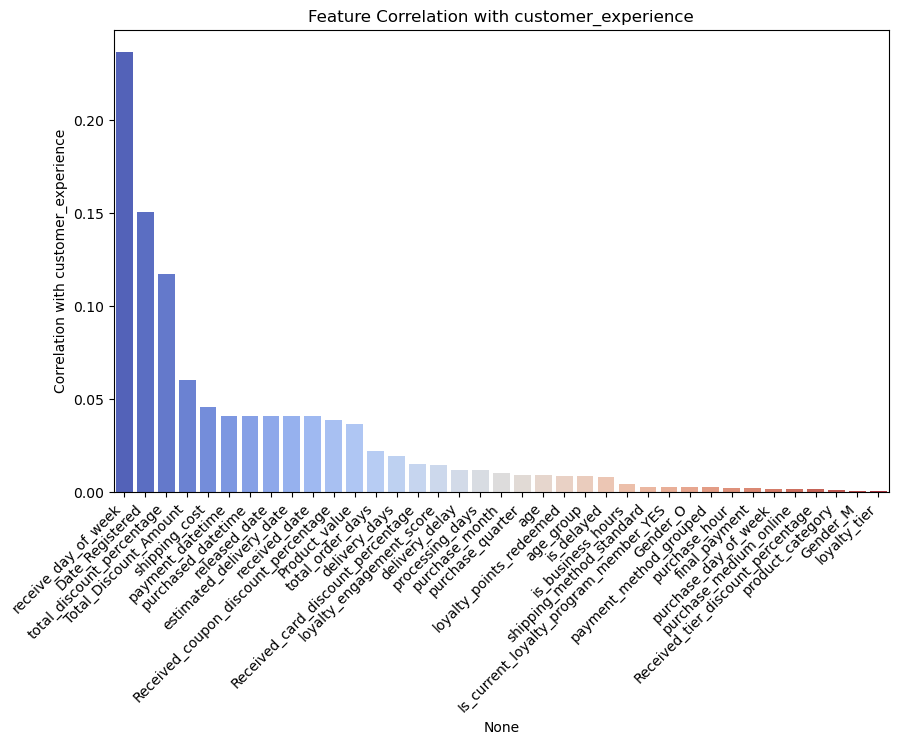

In [129]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calculate correlation matrix
correlation_matrix = df.corr(method='pearson')

target = 'customer_experience'

# Extract correlations for the target
target_corr = correlation_matrix[target].drop(target)

# Sort by correlation strength (absolute value)
target_corr_sorted = target_corr.abs().sort_values(ascending=False)

# Plot bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=target_corr_sorted.index, y=target_corr_sorted.values, palette="coolwarm")
plt.xticks(rotation=45, ha='right')
plt.ylabel('Correlation with ' + target)
plt.title('Feature Correlation with ' + target)
plt.show()


### Splitting Data into Train and Test

In [137]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop("customer_experience",axis=1)

y = df['customer_experience']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, 
                                                    random_state=42, 
                                                    stratify=y)


In [138]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)


(164516, 37)
(41129, 37)
(164516,)
(41129,)


In [141]:
def evaluate_model(model, X_train, X_test, y_train, y_test, model_name):
    print(f"\nTraining {model_name}...")
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    
    # Print performance metrics
    print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
    print(f"F1 Score: {f1_score(y_test, y_pred, average='weighted'):.4f}")
    print("\nClassification Report:\n", classification_report(y_test, y_pred))

    cm = confusion_matrix(y_test, y_pred)

    labels = ['Bad', 'Neutral','Good']
    
    plt.figure(figsize=(5, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, 
                xticklabels=labels, yticklabels=labels)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

In [143]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier, GradientBoostingClassifier
from xgboost import XGBClassifier
from sklearn.metrics import recall_score,precision_score,accuracy_score,f1_score,classification_report,confusion_matrix
from sklearn.neighbors import KNeighborsClassifier

from sklearn.model_selection import train_test_split,GridSearchCV

## Base Model

In [146]:
from sklearn.metrics import accuracy_score,classification_report,f1_score, confusion_matrix

In [148]:
logreg = LogisticRegression(multi_class='ovr', solver='lbfgs', max_iter=400)


Training Logistic Regression(Base)...
Accuracy: 0.5433
F1 Score: 0.5306

Classification Report:
               precision    recall  f1-score   support

           0       0.50      0.46      0.48     13707
           1       0.47      0.32      0.38      9408
           2       0.59      0.73      0.65     18014

    accuracy                           0.54     41129
   macro avg       0.52      0.50      0.50     41129
weighted avg       0.53      0.54      0.53     41129



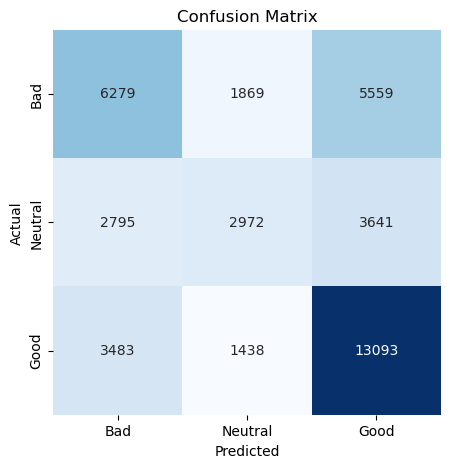

In [150]:
evaluate_model(logreg, X_train, X_test, y_train, y_test, 'Logistic Regression(Base)')

# Decision Tree Classifier

In [152]:
dtc = DecisionTreeClassifier(criterion='gini', random_state=42)


Training Decision Tree Classifier...
Accuracy: 0.5325
F1 Score: 0.5327

Classification Report:
               precision    recall  f1-score   support

           0       0.46      0.47      0.47     13707
           1       0.56      0.57      0.56      9408
           2       0.57      0.56      0.57     18014

    accuracy                           0.53     41129
   macro avg       0.53      0.53      0.53     41129
weighted avg       0.53      0.53      0.53     41129



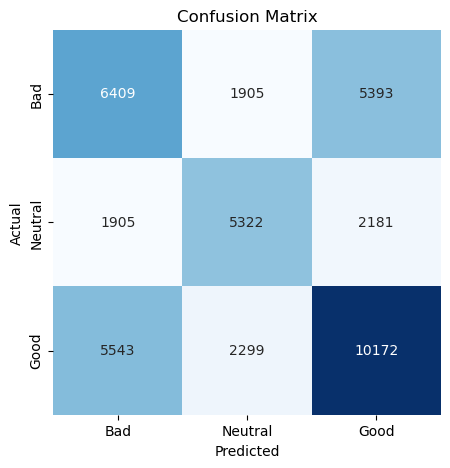

In [154]:
evaluate_model(dtc, X_train, X_test, y_train, y_test, 'Decision Tree Classifier')

# Random Forest Classifier

In [163]:
rf_model = RandomForestClassifier(n_estimators=100, criterion='gini', random_state=42)


Training Random Forest Classifier...
Accuracy: 0.6173
F1 Score: 0.6180

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.57      0.56     13707
           1       0.59      0.61      0.60      9408
           2       0.69      0.66      0.67     18014

    accuracy                           0.62     41129
   macro avg       0.61      0.61      0.61     41129
weighted avg       0.62      0.62      0.62     41129



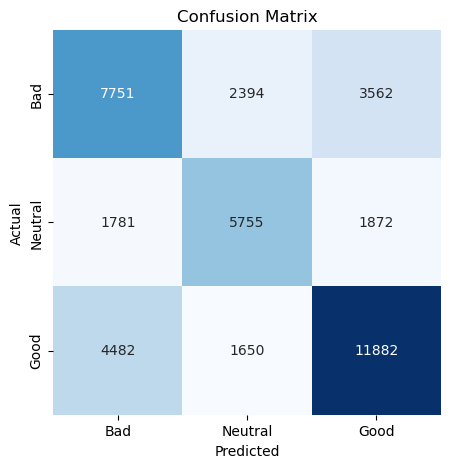

In [165]:
evaluate_model(rf_model, X_train, X_test, y_train, y_test, 'Random Forest Classifier')

# Random Forest Classifier Tuned

In [205]:
grid = {
    'n_estimators': [100,120],             # Number of trees
    'max_depth': [3,5,7],                  # Tree depth
    'min_samples_leaf': [1, 2, 4]          # Minimum samples per leaf
}


grid_rf=GridSearchCV(estimator=RandomForestClassifier(),cv=2,scoring="accuracy",param_grid=grid)
grid_rf.fit(X_train,y_train)
print(grid_rf.best_params_)
print(grid_rf.best_score_)

{'max_depth': 7, 'min_samples_leaf': 2, 'n_estimators': 120}
0.5839614384011281


In [168]:
rf2_model = RandomForestClassifier(max_depth= 7, min_samples_leaf= 2, n_estimators= 120,random_state=42)


Training Random Forest Classifier Tuned...
Accuracy: 0.5839
F1 Score: 0.5843

Classification Report:
               precision    recall  f1-score   support

           0       0.55      0.48      0.51     13707
           1       0.48      0.60      0.53      9408
           2       0.68      0.65      0.66     18014

    accuracy                           0.58     41129
   macro avg       0.57      0.58      0.57     41129
weighted avg       0.59      0.58      0.58     41129



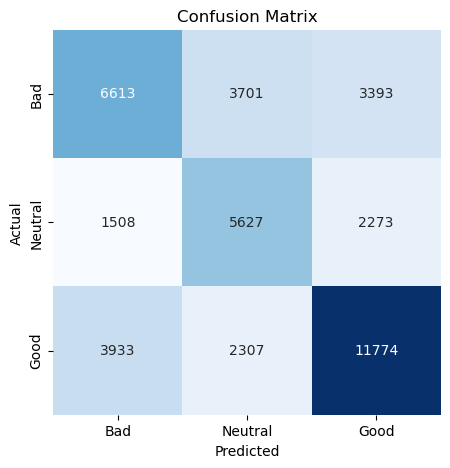

In [170]:
evaluate_model(rf2_model, X_train, X_test, y_train, y_test, 'Random Forest Classifier Tuned')

# Adaboost Classifier  

In [173]:
ada = AdaBoostClassifier(n_estimators=100, random_state=42)


Training Adaboost Classifier...
Accuracy: 0.5787
F1 Score: 0.5813

Classification Report:
               precision    recall  f1-score   support

           0       0.53      0.50      0.51     13707
           1       0.47      0.62      0.54      9408
           2       0.69      0.62      0.66     18014

    accuracy                           0.58     41129
   macro avg       0.57      0.58      0.57     41129
weighted avg       0.59      0.58      0.58     41129



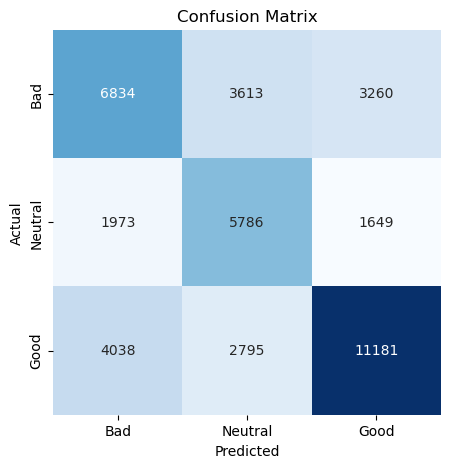

In [175]:
evaluate_model(ada, X_train, X_test, y_train, y_test, 'Adaboost Classifier')

# Gradient Boosting Classifier

In [178]:
gb=GradientBoostingClassifier(random_state=2)


Training Gradient Boosting Classifier...
Accuracy: 0.6335
F1 Score: 0.6346

Classification Report:
               precision    recall  f1-score   support

           0       0.56      0.59      0.58     13707
           1       0.61      0.66      0.63      9408
           2       0.71      0.66      0.68     18014

    accuracy                           0.63     41129
   macro avg       0.63      0.63      0.63     41129
weighted avg       0.64      0.63      0.63     41129



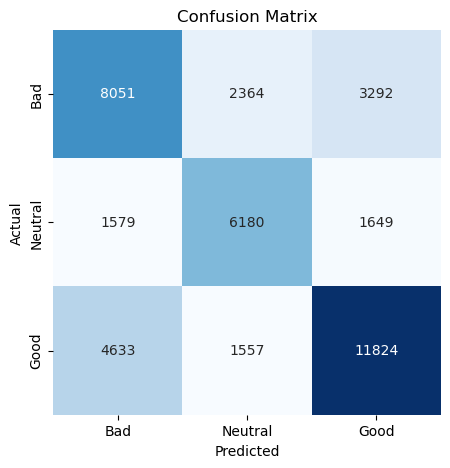

In [180]:
evaluate_model(gb, X_train, X_test, y_train, y_test, 'Gradient Boosting Classifier')

# XG Boost Classifier

In [182]:
xg=XGBClassifier(randon_state=2)


Training XGBoostClassifier...
Accuracy: 0.6668
F1 Score: 0.6678

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.64      0.61     13707
           1       0.71      0.72      0.72      9408
           2       0.71      0.66      0.68     18014

    accuracy                           0.67     41129
   macro avg       0.67      0.67      0.67     41129
weighted avg       0.67      0.67      0.67     41129



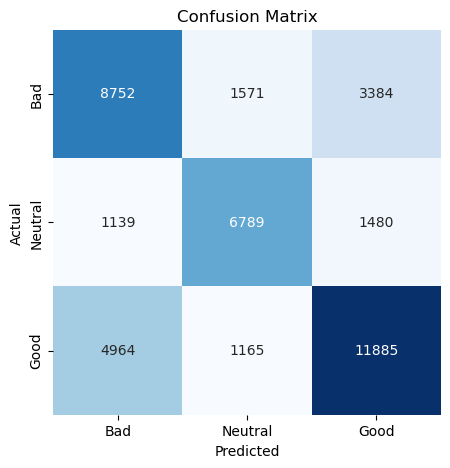

In [184]:
evaluate_model(xg, X_train, X_test, y_train, y_test, 'XGBoostClassifier')

# XG Boost Classifier Tuned

In [219]:
grid = {
    'n_estimators': [100,120,150],          # Number of boosting rounds (trees)
    'max_depth': [3, 5, 7, 10],               # Depth of each tree
    'learning_rate': [0.01,0.1, 0.2]   # Shrinkage rate
}


grid_xg=GridSearchCV(estimator=XGBClassifier(random_state=2),cv=3,scoring="accuracy",param_grid=grid)
grid_xg.fit(X_train,y_train)
print(grid_xg.best_params_)
print(grid_xg.best_score_)

{'learning_rate': 0.1, 'max_depth': 10, 'n_estimators': 100}
0.6704515036627384


In [186]:
xg1=XGBClassifier(learning_rate= 0.1, max_depth= 10, n_estimators= 100)


Training XGBoostClassifier Tuned...
Accuracy: 0.6740
F1 Score: 0.6753

Classification Report:
               precision    recall  f1-score   support

           0       0.59      0.65      0.62     13707
           1       0.74      0.73      0.73      9408
           2       0.71      0.66      0.69     18014

    accuracy                           0.67     41129
   macro avg       0.68      0.68      0.68     41129
weighted avg       0.68      0.67      0.68     41129



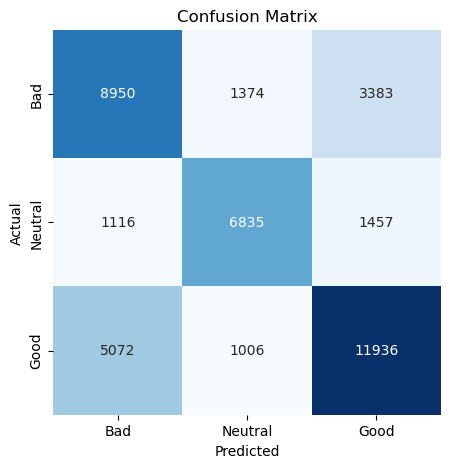

In [188]:
evaluate_model(xg1, X_train, X_test, y_train, y_test, 'XGBoostClassifier Tuned')

# Final Model Analysis

## Cross Val score

In [191]:
from sklearn.model_selection import cross_val_score,KFold

cv = KFold(n_splits=5, shuffle=True, random_state=42)

acc_scores = cross_val_score(xg1, X, y, cv=cv, scoring="accuracy")

In [193]:
print(acc_scores)

[0.67453622 0.67509543 0.67439033 0.6725668  0.67587347]


## Train-Test model analysis

In [196]:
train_accuracy = xg1.score(X_train, y_train)
test_accuracy = xg1.score(X_test, y_test)

print("Train Accuracy--",train_accuracy)
print("Test Accuracy--",test_accuracy)

Train Accuracy-- 0.7431192102895767
Test Accuracy-- 0.6740013129422062
